1. **Nazioni con più incidenti**: mostra quali paesi hanno avuto il maggior numero di incidenti aerei registrati.
2. **Distribuzione settimanale**: analizza se alcuni giorni della settimana hanno più incidenti rispetto ad altri.
3. **Operatori più sicuri**: identifica gli operatori con meno incidenti o nessuna fatalità.
4. **Tipo di velivolo più pericoloso**: individua i modelli con il maggior numero di vittime.
5. **Evoluzione post 11 Settembre**: osserva l’andamento degli incidenti dopo il 2001.
6. **Privato vs Linea**: mostra la percentuale di incidenti nei voli privati rispetto a quelli commerciali.
7. **Aerei coinvolti in più incidenti**: evidenzia i codici di registrazione apparsi più volte (esclusi 'unknown').
8. **Incidenti vicino alle festività**: verifica se aumentano nei pressi di eventi importanti o feste.
9. **Vittime annuali**: traccia l’andamento del numero totale di vittime nel tempo.


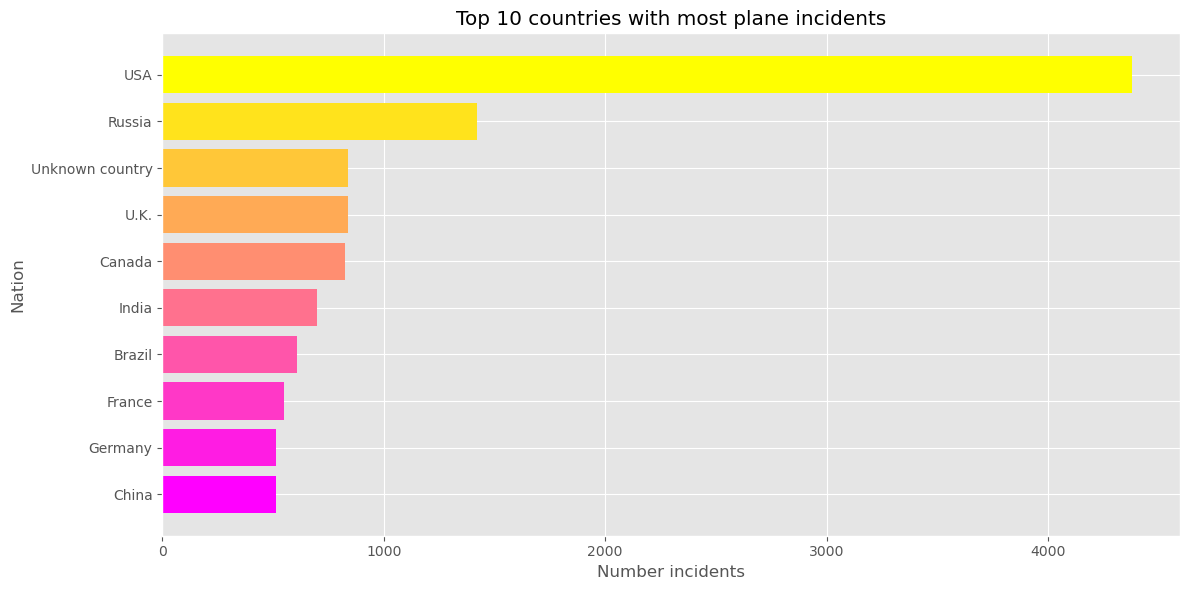

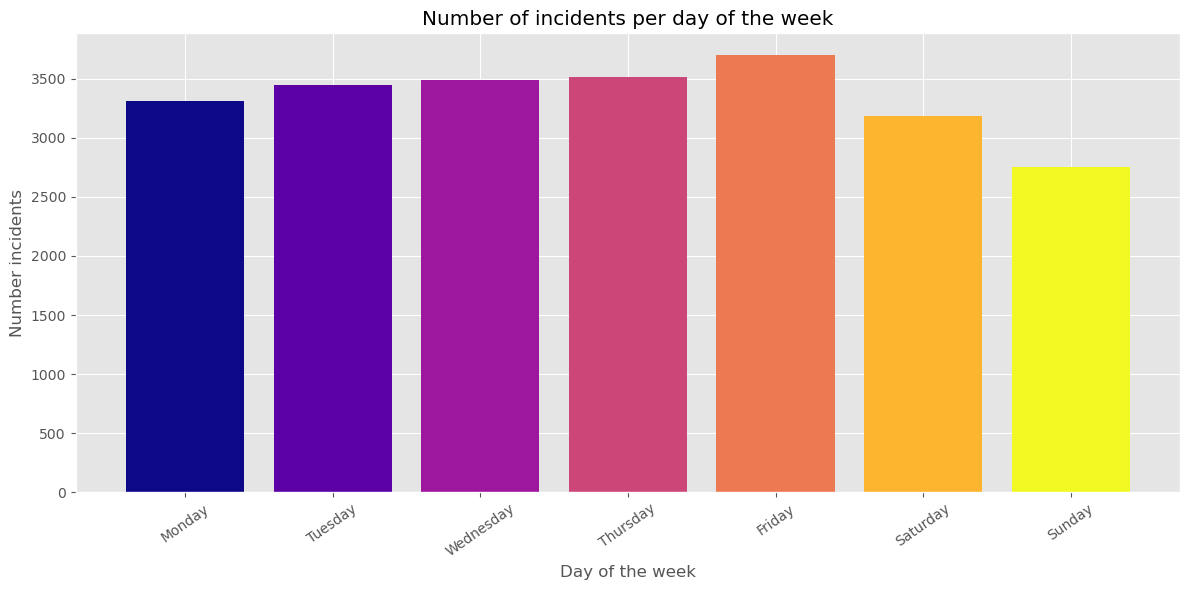

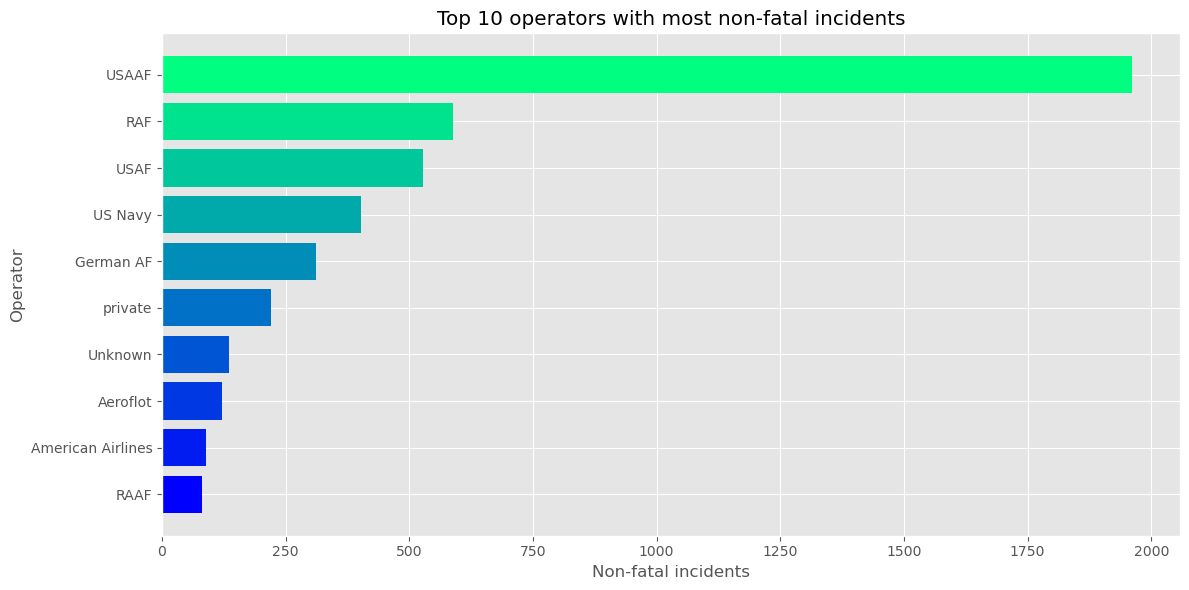

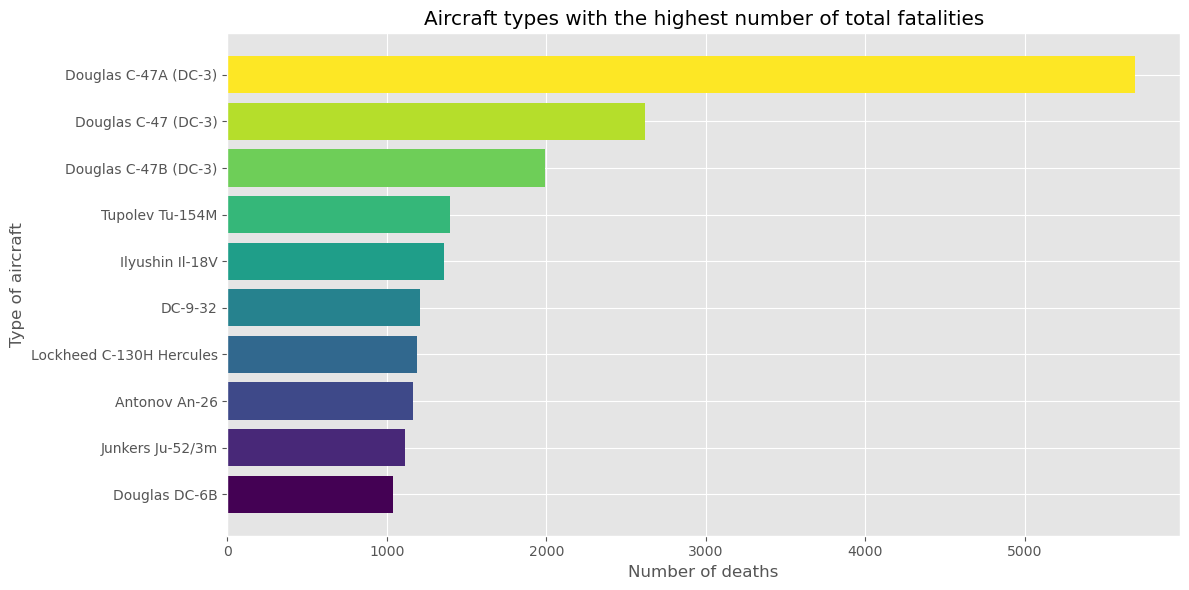

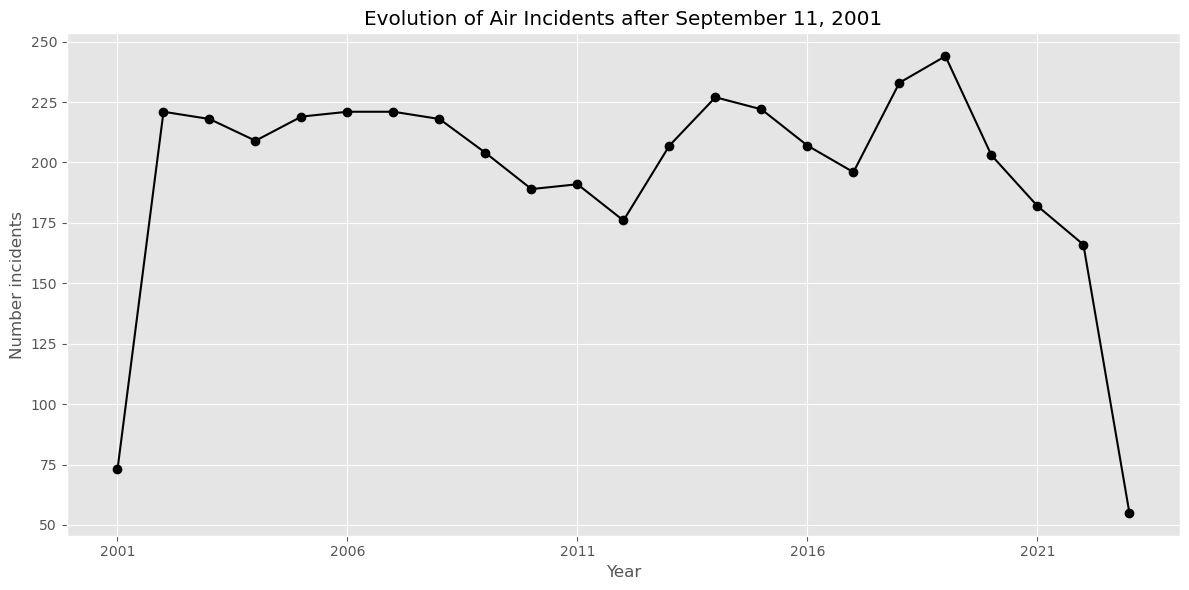

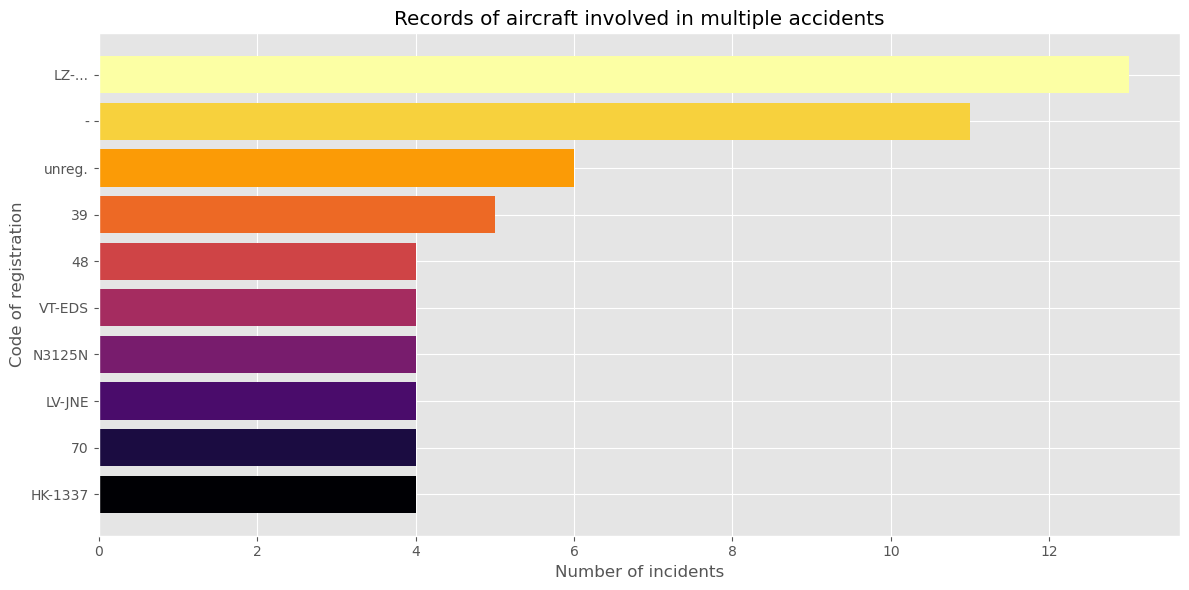

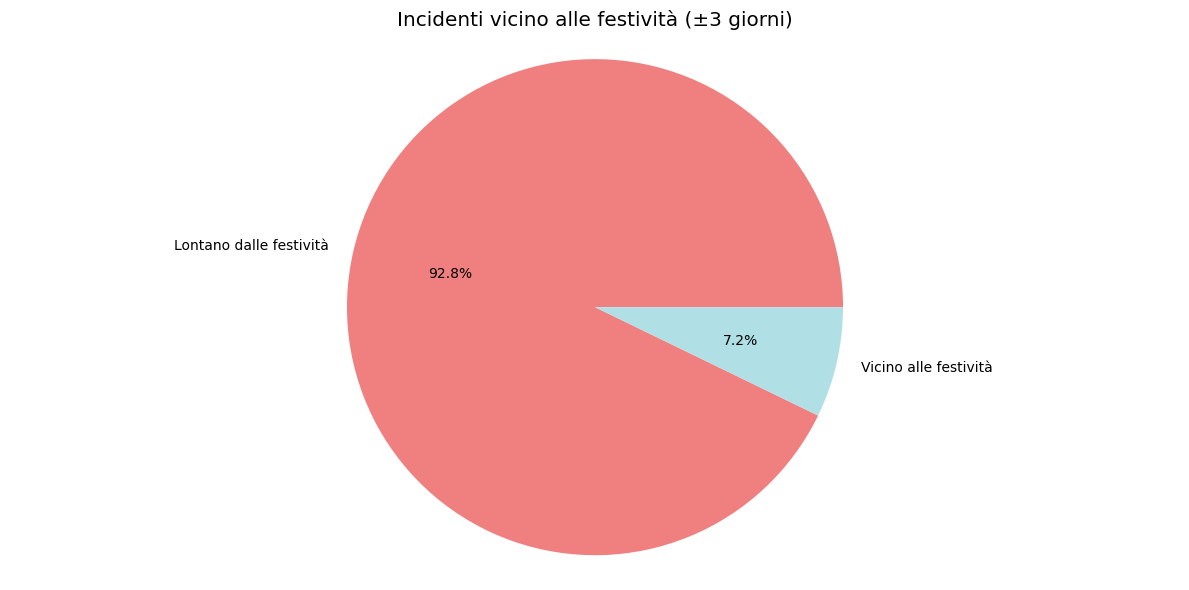

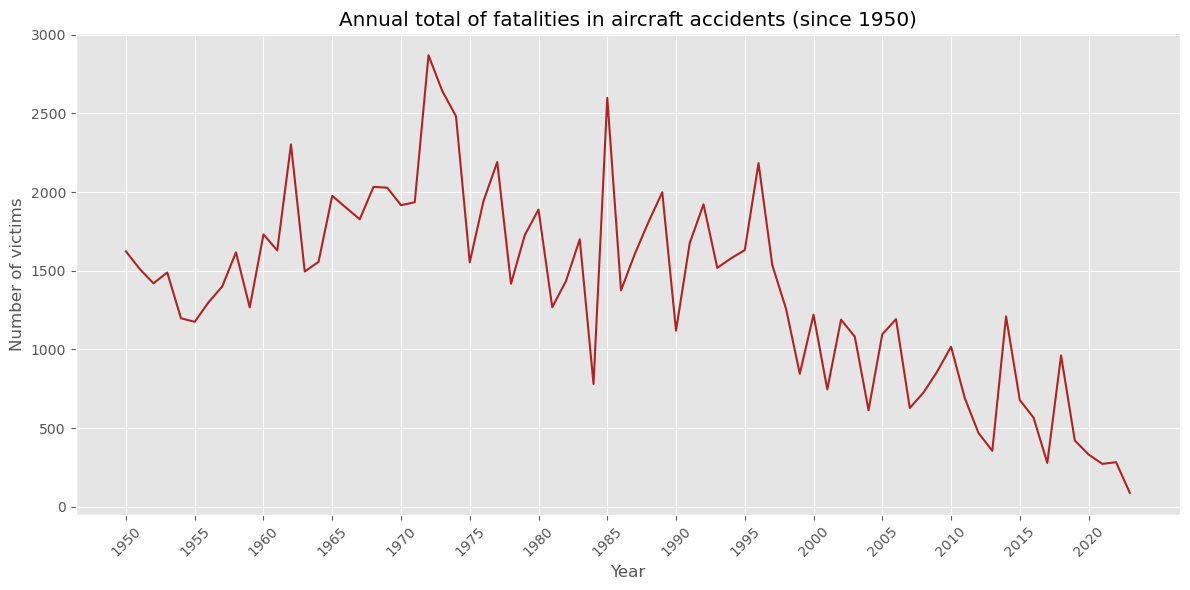

In [27]:
import csv
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from datetime import datetime

insights = [
    "1. **Nazioni con più incidenti**: mostra quali paesi hanno avuto il maggior numero di incidenti aerei registrati.",
    "2. **Distribuzione settimanale**: analizza se alcuni giorni della settimana hanno più incidenti rispetto ad altri.",
    "3. **Operatori più sicuri**: identifica gli operatori con meno incidenti o nessuna fatalità.",
    "4. **Tipo di velivolo più pericoloso**: individua i modelli con il maggior numero di vittime.",
    "5. **Evoluzione post 11 Settembre**: osserva l’andamento degli incidenti dopo il 2001.",
    "6. **Privato vs Linea**: mostra la percentuale di incidenti nei voli privati rispetto a quelli commerciali.",
    "7. **Aerei coinvolti in più incidenti**: evidenzia i codici di registrazione apparsi più volte (esclusi 'unknown').",
    "8. **Incidenti vicino alle festività**: verifica se aumentano nei pressi di eventi importanti o feste.",
    "9. **Vittime annuali**: traccia l’andamento del numero totale di vittime nel tempo."
]
for insight in insights:
    print(insight)
    

df = pd.read_csv('aviation-accidents.csv')

df_copy = df.copy()

#date parsing
def parsing_date(d):
    try:
        return datetime.strptime(d, "%d-%b-%Y")
    except:
        #missing date
        return pd.NaT

#converting dates to numbers
df_copy['parsed_date'] = df_copy['date'].apply(parsing_date)
#create weekday column
df_copy['day_of_week'] = df_copy['parsed_date'].dt.day_name()

#fatalities column conversion from string to numbers, errors set to null
df_copy['fatalities'] = pd.to_numeric(df_copy['fatalities'], errors = 'coerce')

#removing rows with null key fields
df_copy = df_copy.dropna(subset=['country', 'operator', 'type'])

#parameters and graphic styles
plt.rcParams["figure.figsize"] = (12, 6)
plt.style.use('ggplot')


"""insight graphic 1"""

top_fatalities_countries = df_copy['country'].value_counts().head(10)
#horizontal bars
colors = plt.cm.spring(np.linspace(0, 1, len(top_fatalities_countries)))

plt.barh(top_fatalities_countries.index[::-1], top_fatalities_countries.values[::-1], color = colors)
plt.title('Top 10 countries with most plane incidents')
plt.xlabel('Number incidents')
plt.ylabel('Nation')
plt.tight_layout()
plt.show()

"""insight graphic 2"""

week_fatalities = df_copy['day_of_week'].value_counts().reindex([
    'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'
])
colors = plt.cm.plasma(np.linspace(0, 1, len(week_fatalities)))

plt.bar(week_fatalities.index, week_fatalities.values, color = colors)
plt.title('Number of incidents per day of the week')
plt.xlabel('Day of the week')
plt.ylabel('Number incidents')
plt.xticks(rotation=35)
plt.tight_layout()
plt.show()

"""insight graphic 3"""

fatal_incidents = df_copy[df_copy['fatalities'] > 0]['operator'].value_counts()
all_incidents = df_copy['operator'].value_counts()
safe_operators = (all_incidents - fatal_incidents).dropna().sort_values(ascending=False).head(10)
colors = plt.cm.winter(np.linspace(0, 1, len(safe_operators)))

plt.barh(safe_operators.index[::-1], safe_operators.values[::-1], color = colors)
plt.title('Top 10 operators with most non-fatal incidents')
plt.xlabel('Non-fatal incidents')
plt.ylabel('Operator')
plt.tight_layout()
plt.show()

"""insight graphic 4"""

groupe_type = df_copy.groupby('type')
fatalities_sum = groupe_type['fatalities'].sum().dropna()
fatalities_sorted = fatalities_sum.sort_values(ascending=False).head(10)
colors = plt.cm.viridis(np.linspace(0, 1, len(fatalities_sorted)))

plt.barh(fatalities_sorted.index[::-1], fatalities_sorted.values[::-1], color = colors)
plt.title('Aircraft types with the highest number of total fatalities')
plt.xlabel('Number of deaths')
plt.ylabel('Type of aircraft')
plt.tight_layout()
plt.show()

"""insight graphic 5"""

after_11_09 = df_copy[df_copy['parsed_date'] > datetime(2001, 9, 11)]
incidents_per_year = after_11_09['parsed_date'].dt.year.value_counts().sort_index()

plt.plot(incidents_per_year.index, incidents_per_year.values, marker='o', color='black')
plt.title("Evolution of Air Incidents after September 11, 2001")
plt.xlabel('Year')
plt.ylabel('Number incidents')
plt.xticks(incidents_per_year.index, incidents_per_year.index)
plt.xticks(range(after_11_09['parsed_date'].dt.year.min(), after_11_09['parsed_date'].dt.year.max() + 1, 5))
plt.grid(True)
plt.tight_layout()
plt.show()

"""insight graphic 6"""

#filter valid registration
valid_reg = df_copy['registration'].dropna()

#counting duplicate registration 
duplicated_reg = valid_reg.value_counts()
multiple_incidents = duplicated_reg[duplicated_reg > 1]
top_ten_incident = multiple_incidents.head(10)
colors = plt.cm.inferno(np.linspace(0, 1, len(top_ten_incident)))

plt.barh(top_ten_incident.index[::-1], top_ten_incident.values[::-1], color = colors)
plt.title('Records of aircraft involved in multiple accidents')
plt.xlabel('Number of incidents')
plt.ylabel('Code of registration')
plt.tight_layout()
plt.show()

"""insight graphic 7"""

def is_near_holiday(date):
    if pd.isna(date):
        return False

    holidays = [
        (1, 1),   # Capodanno
        (12, 25), # Natale
        (12, 31), # San Silvestro
        (8, 15),  # Ferragosto
        (2, 14),  # San Valentino
    ]

    for month, day in holidays:
        try:
            holiday_day = datetime(date.year, month, day)
            if abs((date - holiday_day).days) <= 3:
                return True
        except:
            continue
    return False

df_copy['near_holiday'] = df_copy['parsed_date'].apply(is_near_holiday)

# Count of incidents
incident_counts = df_copy['near_holiday'].value_counts().to_dict()

incident_counts.setdefault(True, 0)
incident_counts.setdefault(False, 0)


labels = ['Lontano dalle festività', 'Vicino alle festività']
sizes = [incident_counts[False], incident_counts[True]]
colors = ['lightcoral', 'powderblue']

plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%')
plt.title('Incidenti vicino alle festività (±3 giorni)')
plt.axis('equal')
plt.tight_layout()
plt.show()

"""insight graphic 8"""

#data cleaning and grouping
annual_fatalities = df_copy.dropna(subset=['parsed_date', 'fatalities'])
annual_fatalities = annual_fatalities.groupby(annual_fatalities['parsed_date'].dt.year)['fatalities'].sum()
annual_fatalities = annual_fatalities[annual_fatalities.index >= 1950]

plt.plot(annual_fatalities.index, annual_fatalities.values, color='firebrick')
plt.title('Annual total of fatalities in aircraft accidents (since 1950)')
plt.xlabel('Year')
plt.ylabel('Number of victims')
plt.grid(True)
plt.xticks(ticks=annual_fatalities.index[::5], labels=annual_fatalities.index[::5], rotation=45)
plt.tight_layout()
plt.show()
